In [1]:
from pynq.overlays.base import BaseOverlay
base = BaseOverlay("base.bit")


In [22]:
# from pynq.lib import MicroblazeLibrary
import time
%load_ext autoreload
%autoreload 2
from OLEDDisplay import OLEDDisplay

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from pynq.lib import MicroblazeLibrary
import time
import numpy as np
from PIL import Image

## Note to run outside of jupyter
# source /etc/profile.d/xrt_setup.sh
# source /usr/local/share/pynq-venv/bin/activate

# define some commands
CHARGEPUMP = 0x8D
COLUMNADDR = 0x21
COMSCANDEC = 0xC8
COMSCANINC = 0xC0
DISPLAYALLON = 0xA5
DISPLAYALLON_RESUME = 0xA4
DISPLAYOFF = 0xAE
DISPLAYON = 0xAF
EXTERNALVCC = 0x1
INVERTDISPLAY = 0xA7
MEMORYMODE = 0x20
NORMALDISPLAY = 0xA6
PAGEADDR = 0x22
SEGREMAP = 0xA0
SETCOMPINS = 0xDA
SETCONTRAST = 0x81
SETDISPLAYCLOCKDIV = 0xD5
SETDISPLAYOFFSET = 0xD3
SETHIGHCOLUMN = 0x10
SETLOWCOLUMN = 0x00
SETMULTIPLEX = 0xA8
SETPRECHARGE = 0xD9
SETSEGMENTREMAP = 0xA1
SETSTARTLINE = 0x40
SETVCOMDETECT = 0xDB
SWITCHCAPVCC = 0x2


# 8x8 Font ASCII 32 - 127 Implemented
# Users can modify this to support more characters(glyphs)
# BasicFont is placed in code memory.
# This font can be freely used without any restriction.
BasicFont = [
  bytearray([0x00,0x00,0x00,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x00,0x5F,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x00,0x07,0x00,0x07,0x00,0x00,0x00]),
  bytearray([0x00,0x14,0x7F,0x14,0x7F,0x14,0x00,0x00]),
  bytearray([0x00,0x24,0x2A,0x7F,0x2A,0x12,0x00,0x00]),
  bytearray([0x00,0x23,0x13,0x08,0x64,0x62,0x00,0x00]),
  bytearray([0x00,0x36,0x49,0x55,0x22,0x50,0x00,0x00]),
  bytearray([0x00,0x00,0x05,0x03,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x1C,0x22,0x41,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x41,0x22,0x1C,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x08,0x2A,0x1C,0x2A,0x08,0x00,0x00]),
  bytearray([0x00,0x08,0x08,0x3E,0x08,0x08,0x00,0x00]),
  bytearray([0x00,0xA0,0x60,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x08,0x08,0x08,0x08,0x08,0x00,0x00]),
  bytearray([0x00,0x60,0x60,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x20,0x10,0x08,0x04,0x02,0x00,0x00]),
  bytearray([0x00,0x3E,0x51,0x49,0x45,0x3E,0x00,0x00]),
  bytearray([0x00,0x00,0x42,0x7F,0x40,0x00,0x00,0x00]),
  bytearray([0x00,0x62,0x51,0x49,0x49,0x46,0x00,0x00]),
  bytearray([0x00,0x22,0x41,0x49,0x49,0x36,0x00,0x00]),
  bytearray([0x00,0x18,0x14,0x12,0x7F,0x10,0x00,0x00]),
  bytearray([0x00,0x27,0x45,0x45,0x45,0x39,0x00,0x00]),
  bytearray([0x00,0x3C,0x4A,0x49,0x49,0x30,0x00,0x00]),
  bytearray([0x00,0x01,0x71,0x09,0x05,0x03,0x00,0x00]),
  bytearray([0x00,0x36,0x49,0x49,0x49,0x36,0x00,0x00]),
  bytearray([0x00,0x06,0x49,0x49,0x29,0x1E,0x00,0x00]),
  bytearray([0x00,0x00,0x36,0x36,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x00,0xAC,0x6C,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x08,0x14,0x22,0x41,0x00,0x00,0x00]),
  bytearray([0x00,0x14,0x14,0x14,0x14,0x14,0x00,0x00]),
  bytearray([0x00,0x41,0x22,0x14,0x08,0x00,0x00,0x00]),
  bytearray([0x00,0x02,0x01,0x51,0x09,0x06,0x00,0x00]),
  bytearray([0x00,0x32,0x49,0x79,0x41,0x3E,0x00,0x00]),
  bytearray([0x00,0x7E,0x09,0x09,0x09,0x7E,0x00,0x00]),
  bytearray([0x00,0x7F,0x49,0x49,0x49,0x36,0x00,0x00]),
  bytearray([0x00,0x3E,0x41,0x41,0x41,0x22,0x00,0x00]),
  bytearray([0x00,0x7F,0x41,0x41,0x22,0x1C,0x00,0x00]),
  bytearray([0x00,0x7F,0x49,0x49,0x49,0x41,0x00,0x00]),
  bytearray([0x00,0x7F,0x09,0x09,0x09,0x01,0x00,0x00]),
  bytearray([0x00,0x3E,0x41,0x41,0x51,0x72,0x00,0x00]),
  bytearray([0x00,0x7F,0x08,0x08,0x08,0x7F,0x00,0x00]),
  bytearray([0x00,0x41,0x7F,0x41,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x20,0x40,0x41,0x3F,0x01,0x00,0x00]),
  bytearray([0x00,0x7F,0x08,0x14,0x22,0x41,0x00,0x00]),
  bytearray([0x00,0x7F,0x40,0x40,0x40,0x40,0x00,0x00]),
  bytearray([0x00,0x7F,0x02,0x0C,0x02,0x7F,0x00,0x00]),
  bytearray([0x00,0x7F,0x04,0x08,0x10,0x7F,0x00,0x00]),
  bytearray([0x00,0x3E,0x41,0x41,0x41,0x3E,0x00,0x00]),
  bytearray([0x00,0x7F,0x09,0x09,0x09,0x06,0x00,0x00]),
  bytearray([0x00,0x3E,0x41,0x51,0x21,0x5E,0x00,0x00]),
  bytearray([0x00,0x7F,0x09,0x19,0x29,0x46,0x00,0x00]),
  bytearray([0x00,0x26,0x49,0x49,0x49,0x32,0x00,0x00]),
  bytearray([0x00,0x01,0x01,0x7F,0x01,0x01,0x00,0x00]),
  bytearray([0x00,0x3F,0x40,0x40,0x40,0x3F,0x00,0x00]),
  bytearray([0x00,0x1F,0x20,0x40,0x20,0x1F,0x00,0x00]),
  bytearray([0x00,0x3F,0x40,0x38,0x40,0x3F,0x00,0x00]),
  bytearray([0x00,0x63,0x14,0x08,0x14,0x63,0x00,0x00]),
  bytearray([0x00,0x03,0x04,0x78,0x04,0x03,0x00,0x00]),
  bytearray([0x00,0x61,0x51,0x49,0x45,0x43,0x00,0x00]),
  bytearray([0x00,0x7F,0x41,0x41,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x02,0x04,0x08,0x10,0x20,0x00,0x00]),
  bytearray([0x00,0x41,0x41,0x7F,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x04,0x02,0x01,0x02,0x04,0x00,0x00]),
  bytearray([0x00,0x80,0x80,0x80,0x80,0x80,0x00,0x00]),
  bytearray([0x00,0x01,0x02,0x04,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x20,0x54,0x54,0x54,0x78,0x00,0x00]),
  bytearray([0x00,0x7F,0x48,0x44,0x44,0x38,0x00,0x00]),
  bytearray([0x00,0x38,0x44,0x44,0x28,0x00,0x00,0x00]),
  bytearray([0x00,0x38,0x44,0x44,0x48,0x7F,0x00,0x00]),
  bytearray([0x00,0x38,0x54,0x54,0x54,0x18,0x00,0x00]),
  bytearray([0x00,0x08,0x7E,0x09,0x02,0x00,0x00,0x00]),
  bytearray([0x00,0x18,0xA4,0xA4,0xA4,0x7C,0x00,0x00]),
  bytearray([0x00,0x7F,0x08,0x04,0x04,0x78,0x00,0x00]),
  bytearray([0x00,0x00,0x7D,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x80,0x84,0x7D,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x7F,0x10,0x28,0x44,0x00,0x00,0x00]),
  bytearray([0x00,0x41,0x7F,0x40,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x7C,0x04,0x18,0x04,0x78,0x00,0x00]),
  bytearray([0x00,0x7C,0x08,0x04,0x7C,0x00,0x00,0x00]),
  bytearray([0x00,0x38,0x44,0x44,0x38,0x00,0x00,0x00]),
  bytearray([0x00,0xFC,0x24,0x24,0x18,0x00,0x00,0x00]),
  bytearray([0x00,0x18,0x24,0x24,0xFC,0x00,0x00,0x00]),
  bytearray([0x00,0x00,0x7C,0x08,0x04,0x00,0x00,0x00]),
  bytearray([0x00,0x48,0x54,0x54,0x24,0x00,0x00,0x00]),
  bytearray([0x00,0x04,0x7F,0x44,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x3C,0x40,0x40,0x7C,0x00,0x00,0x00]),
  bytearray([0x00,0x1C,0x20,0x40,0x20,0x1C,0x00,0x00]),
  bytearray([0x00,0x3C,0x40,0x30,0x40,0x3C,0x00,0x00]),
  bytearray([0x00,0x44,0x28,0x10,0x28,0x44,0x00,0x00]),
  bytearray([0x00,0x1C,0xA0,0xA0,0x7C,0x00,0x00,0x00]),
  bytearray([0x00,0x44,0x64,0x54,0x4C,0x44,0x00,0x00]),
  bytearray([0x00,0x08,0x36,0x41,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x00,0x7F,0x00,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x41,0x36,0x08,0x00,0x00,0x00,0x00]),
  bytearray([0x00,0x02,0x01,0x01,0x02,0x01,0x00,0x00]),
  bytearray([0x00,0x02,0x05,0x05,0x02,0x00,0x00,0x00]) 
]


class OLEDDisplay():
    def __init__(self, pmod):
        self.display_height = 64
        self.display_width = 128

        #alocate buffer
        self.buffer_size = int(self.display_height*self.display_width/8)
        self.buffer = bytearray(self.buffer_size)
        self.buffer_view = memoryview(self.buffer)

        # load i2c microblaze
        self.liba = MicroblazeLibrary(pmod, ['i2c'])

        self.curser_x = 0
        self.curser_y = 0

    def connect(self, sda=3, scl=7):
        self.device = self.liba.i2c_open(sda, scl)
        time.sleep(0.01)
        self.display_init()
        self.clear()
        self.flush()
    
    def display_init(self):
        self.send_command(DISPLAYOFF)
        self.send_command(SETDISPLAYCLOCKDIV)
        self.send_command(0xF0) # Increase speed of the display max ~96Hz
        self.send_command(SETMULTIPLEX)
        self.send_command(self.display_height - 1)
        self.send_command(SETDISPLAYOFFSET)
        self.send_command(0x00)
        self.send_command(SETSTARTLINE)
        self.send_command(CHARGEPUMP)
        self.send_command(0x14)
        self.send_command(MEMORYMODE)
        self.send_command(0x00)
        self.send_command(SEGREMAP)
        self.send_command(COMSCANINC)
        self.send_command(SETCOMPINS)
        self.send_command(0x12)
        self.send_command(SETCONTRAST)
        self.send_command(0xCF)
        self.send_command(SETPRECHARGE)
        self.send_command(0xF1)
        self.send_command(SETVCOMDETECT) #0xDB, (additionally needed to lower the contrast)
        self.send_command(0x40) #0x40 default, to lower the contrast, put 0
        self.send_command(DISPLAYALLON_RESUME)
        self.send_command(NORMALDISPLAY)
        self.send_command(0x2e)            # stop scroll
        self.send_command(DISPLAYON)
    
    def send_command(self, cmd):
        data_buf = bytearray(2)
        data_buf[0] = 0x80 # conrol command
        data_buf[1] = cmd
        self.device.write(0x3c, data_buf, 2)

    def flush(self):
        self.send_command(MEMORYMODE)
        self.send_command(0x00)
        self.send_command(COLUMNADDR)
        self.send_command(0)        # column start address (0 = reset)
        self.send_command(127)      # column end address (127 = reset)
        self.send_command(PAGEADDR)
        self.send_command(0x00)     # page start address (0 = reset)
        self.send_command(0x07)
        
        # For whatever reason when I write the full screen in a single
        # write it locks up the MicroBlaze
        packet = bytearray(513)
        packet[0] = 0x40
        packet[1:] = self.buffer_view[:512]
        self.device.write(0x3c, packet, 513)
        packet[1:] = self.buffer_view[512:] 
        self.device.write(0x3c, packet, 513)
        
    def clear(self):
        self.buffer[:] = bytearray(self.buffer_size)
    
    def _write_symbol(self, symbol:bytearray, x, y):
        start = y*128+x
        self.buffer[start:start+len(symbol)] = symbol

    def write_basic_str(self, s:str, x=0, y=0):
        for c in s:
            y += x//128
            x = x%128
            y = y % 8
            a = ord(c)-32
            if a<0 or a>95:
                a=0 # default to space
            self._write_symbol(BasicFont[a], x, y)
            x+=8

    def remap_for_display(self, bitmap):
        # assume it is a 128 by 64 1 bit bitmap
        # we need to convert to the correct format 
        # for writing to the OLED which is each byte
        # represents a vertical slice 8 pixels tall
        bitmap = np.frombuffer(bitmap, dtype=np.uint8).reshape(self.display_height,self.display_width//8)
        bitmap = np.unpackbits(bitmap, axis=1)
        bitmap = np.packbits(bitmap, axis=0, bitorder='little')
        #bitmap = np.flip(bitmap)
        return bytearray(bitmap)

    def display_jpg(self, img):
        img = img.resize((self.display_width, self.display_height))
        img = img.convert('1')
        self.buffer[:] = self.remap_for_display(img.tobytes())
        self.flush()


In [15]:
disp = OLEDDisplay(base.PMODB)
disp.connect()

In [16]:
disp.write_basic_str("  Hello world!  blabla")
disp.flush()

In [6]:
from PIL import Image
from IPython.display import display


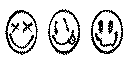

In [13]:


img = Image.open("Smily_faces.jpg")

img_btm = img.resize((128,64))

img_btm = img_btm.convert('1')
display(img_btm)
disp.display_jpg(img)


In [115]:
import numpy as np
print(np.frombuffer(img.tobytes(), dtype=np.uint8))
raw_img = bytearray(img.tobytes())
# disp.buffer[:] = raw_img
# disp.flush()

[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 253 191 255 255 255 255 255 255 255 255 255
 160 255 255 255 255 224  23 255 255 255 254   2 255 255 255 254   0  63
 255 255 255 192  67 255 255 255 240  72 127 255 255 252   5   7 255 255
 255  15 168 255 255 255 227 250  31 255 255 248  95  71 255 255 254  63
 248 127 255 255 199 255  15 255 255 240 255 241 255 255 252 255 254  63
 255 255 143 255 199 255 255 225 255 248 255 255 24

In [95]:
lines = bytearray((b'\xff'*16 + b'\x00'*16)*32)
disp.buffer[:] = lines
disp.flush()

In [108]:
import numpy as np
display_height = 64
display_width = 128
np.set_printoptions(threshold=np.inf)
def remap_for_display(bitmap):
    # assume it is a 128 by 64 1 bit bitmap
    # we need to convert to the correct format 
    # for writing to the OLED which is each byte
    # represents a vertical slice 8 pixels tall
    width = display_width
    height = display_height
    bitmap = np.array(bitmap).reshape(height,width//8)
    bitmap = np.unpackbits(bitmap, axis=1)
    bitmap = np.packbits(bitmap, axis=0)
    bitmap = np.flip(bitmap)
    return bytearray(bitmap)
        


    

In [109]:
new_lines = remap_for_display(lines)
disp.buffer[:] = new_lines
disp.flush()

In [110]:
new_img = remap_for_display(raw_img)
disp.buffer[:] = new_img
disp.flush()

In [4]:
from pynq.lib import MicroblazeLibrary
liba = MicroblazeLibrary(base.PMODA, ['i2c'])
device = liba.i2c_open(3,7)


In [7]:
def display():
    x_offset = 0
    send_command(MEMORYMODE)
    send_command(0x00)

    send_command(COLUMNADDR)
    send_command(0)                      # column start address (0 = reset)
    send_command(127)# column end address (127 = reset)

    send_command(PAGEADDR)
    send_command(0x00)                           # page start address (0 = reset)
    send_command(0x07)
    print(f"writing: {full_buffer[:128]}")
    device.write(0x3c, full_buffer[:513], 513)
    device.write(0x3c, full_buffer[:513], 513)
    
    return 
    
    full_buffer[0] = 0x40 # control
#     test_buffer = bytearray([0x40, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00])
    for i in range(7):
        send_command(PAGEADDR)
        send_command(i)                           # page start address (0 = reset)
        send_command(0x07)
        print(f"sending range {i*128}:{128+i*128}")
        device.write(0x3c, bytearray(0x40)+bytearray([0x0F, 0xF0]*64), 128)

In [9]:
init_SSD_1306()

In [11]:
# clear screen 
display_buf[0::2] = b'\xFF' * (len(display_buf) // 2)
display()
# send_command(DISPLAYALLON_RESUME)

writing: bytearray(b'@\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff\x00\xff')


In [56]:
# dir(device)
data_buf = bytearray(2)
dat_cmd = 0b0 # if command 0 if data 1
data_buf[0] = 0b00000000
data_buf[1] = 0xAF
device.write(0x3c, data_buf, 2)


2

In [ ]:
adr = 0x3C
cmd = bytearray()
device.write(adr,)

In [17]:
from pynq import PL
PL.reset()

In [4]:
%%microblaze base.PMODA
#include "i2c.h"

#define OLED_Address            0x3c
#define OLED_Command_Mode       0x80
#define OLED_Data_Mode          0x40

#define CHARGEPUMP 0x8D
#define DISPLAYALLON 0xA5
#define DISPLAYALLON_RESUME 0xA4
#define DISPLAYOFF 0xAE
#define DISPLAYON 0xAF
#define SETPRECHARGE 0xD9
#define SETVCOMDETECT 0xDB
#define NORMALDISPLAY 0xA6


void sendCommand(unsigned char command);
void sendData(unsigned char Data);
void oled_init();

static i2c device;

void sendCommand(unsigned char command){
   unsigned char buffer[2];
   buffer[0] = OLED_Command_Mode;
   buffer[1] = command;
   i2c_write(device, OLED_Address, buffer, 2);
}

void sendData(unsigned char data){
   unsigned char buffer[2];
   buffer[0] = OLED_Data_Mode;
   buffer[1] = data;
   i2c_write(device, OLED_Address, buffer, 2);
}

void oled_init(){
    sendCommand(DISPLAYOFF);
    sendCommand(CHARGEPUMP);
    sendCommand(0x14);
    sendCommand(SETPRECHARGE);
    sendCommand(0xF1);
    sendCommand(SETVCOMDETECT);
    sendCommand(0x40);
    sendCommand(DISPLAYALLON_RESUME);
    sendCommand(NORMALDISPLAY);
    sendCommand(0x2e);
    sendCommand(DISPLAYON);
}

void oled_connect(int sda, int scl){
    device = i2c_open(sda, scl);
    oled_init();
}



In [15]:
oled_connect(3,7)

NameError: name 'init' is not defined

In [16]:
for i in range(255):
    sendData(0x0F)

In [10]:
send_command(DISPLAYOFF)

typedef uint8_t containing 1

In [12]:
send_command(DISPLAYOFF);
send_command(SETDISPLAYCLOCKDIV);
send_command(0xF0); # Increase speed of the display max ~96Hz
send_command(SETMULTIPLEX);
send_command(displayHeight - 1);
send_command(SETDISPLAYOFFSET);
send_command(0x00);
send_command(SETSTARTLINE);
send_command(CHARGEPUMP);
send_command(0x14);
send_command(MEMORYMODE);
send_command(0x00);
send_command(SEGREMAP);
send_command(COMSCANINC);
send_command(SETCOMPINS);
send_command(0x12);
send_command(SETCONTRAST);
send_command(0xCF);
send_command(SETPRECHARGE);
send_command(0xF1);
send_command(SETVCOMDETECT); #0xDB, (additionally needed to lower the contrast)
send_command(0x40); #0x40 default, to lower the contrast, put 0
send_command(DISPLAYALLON_RESUME);
send_command(NORMALDISPLAY);
send_command(0x2e);            # stop scroll
send_command(DISPLAYON);


KeyboardInterrupt



In [13]:
# bitmap
# 'Smily_faces', 128x64px
bitmap_Smily_faces = bytearray([
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0x7f, 0x3f, 0x0f, 0x8f, 0xc7, 0xe3, 0xf3, 0xf1, 
    0xf9, 0xf9, 0xf8, 0xf8, 0xfc, 0xfc, 0xfc, 0xfd, 0xf9, 0xf9, 0xf9, 0xfb, 0xf3, 0xf7, 0xe7, 0xcf, 
    0x9f, 0x3f, 0x7f, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0x7f, 0x9f, 0xcf, 0xe7, 0xf7, 0xf3, 0xf9, 0xf9, 0xfd, 0xfc, 0xfc, 0xfc, 0x7c, 
    0x3c, 0x3c, 0xfc, 0xfc, 0xfd, 0xf9, 0xf9, 0xf3, 0xf7, 0xe7, 0xcf, 0x9f, 0x3f, 0x7f, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0x7f, 0x3f, 0x1f, 
    0x8f, 0xe7, 0xe3, 0xf3, 0xf9, 0x79, 0xfd, 0xfd, 0xfc, 0xfc, 0xfc, 0xfc, 0xfc, 0xfc, 0xfd, 0xfd, 
    0xf9, 0xf9, 0xf3, 0xf3, 0xe7, 0xcf, 0x9f, 0x3f, 0x7f, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0x0f, 0x01, 0xf0, 0xfc, 0xff, 0xf3, 0x73, 0x33, 0x87, 0xc7, 
    0xc7, 0xc3, 0xb9, 0xff, 0xff, 0xff, 0xff, 0x7c, 0x19, 0x99, 0xc3, 0xc7, 0xc7, 0xc3, 0x73, 0xf1, 
    0xf3, 0xff, 0xfc, 0xf0, 0x03, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0x7f, 0x03, 0xf0, 0xfe, 0xff, 0xff, 0xff, 0x00, 0x38, 0x7f, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xfe, 0xfc, 0xe1, 0x07, 0x1f, 0xff, 0xff, 0xff, 0x7f, 0x7f, 0xff, 0xff, 0xfe, 0xf8, 0x01, 0x07, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0x0f, 0x01, 0xf8, 0xfe, 0xff, 
    0xff, 0xff, 0xf9, 0x00, 0x00, 0x00, 0x00, 0xff, 0xff, 0xff, 0xff, 0xff, 0x0f, 0x00, 0x00, 0x00, 
    0x80, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xfe, 0xf8, 0x01, 0x0f, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xe0, 0x80, 0x1f, 0x79, 0xe1, 0x83, 0x1e, 0x3f, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0x7f, 0x1f, 0x87, 
    0xc3, 0xe3, 0x7f, 0x0f, 0xc0, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xf8, 0xc0, 0x0f, 0x3f, 0xf3, 0xe3, 0x87, 0x1e, 0x3c, 0x7e, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0x7f, 0x7f, 0x1f, 0x1f, 0x0f, 0xe1, 0xd0, 0x92, 0x07, 0x0f, 0x7f, 0x0f, 0x80, 0xe0, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xe0, 0x80, 0x0f, 0x3f, 0xf1, 
    0xc1, 0xc3, 0x8f, 0x9f, 0x1e, 0x3e, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xfe, 0xfe, 0xfe, 
    0xff, 0xff, 0x7f, 0x00, 0x80, 0xf0, 0xff, 0x7f, 0x0f, 0x80, 0xf0, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xfe, 0xf8, 0xf1, 0xe3, 0xe7, 0xce, 0xce, 0x9c, 
    0x99, 0xbb, 0x3b, 0x33, 0x37, 0x37, 0x37, 0x37, 0x33, 0x3b, 0xb9, 0x9d, 0x9c, 0xce, 0xc7, 0xe7, 
    0xf3, 0xf8, 0xfc, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xfc, 0xf8, 0xf1, 0xe3, 0xe7, 0xcf, 0x8e, 0x9e, 0x9e, 0x1c, 0x3c, 0x3c, 0x3e, 
    0x3e, 0x3e, 0x3e, 0x3f, 0x1f, 0x9e, 0x8e, 0x8e, 0xc6, 0xe2, 0xf0, 0xf8, 0xfc, 0xfe, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xfe, 0xfc, 0xf8, 
    0xf1, 0xe3, 0xc7, 0xcf, 0x8e, 0x9c, 0x99, 0x19, 0x39, 0x39, 0x39, 0x3d, 0x3d, 0x3d, 0x1d, 0x9d, 
    0x99, 0x88, 0xcc, 0xe7, 0xe3, 0xf3, 0xf8, 0xfc, 0xfe, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xfe, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 
    0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff]
)


In [14]:
disp.buffer[:] = bitmap_Smily_faces


In [15]:
disp.flush()

In [1]:
import sys
print(sys.executable)   

/usr/local/share/pynq-venv/bin/python3
